In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv('./Logestic_regression/diabetes.csv')

In [4]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
data.shape

(768, 9)

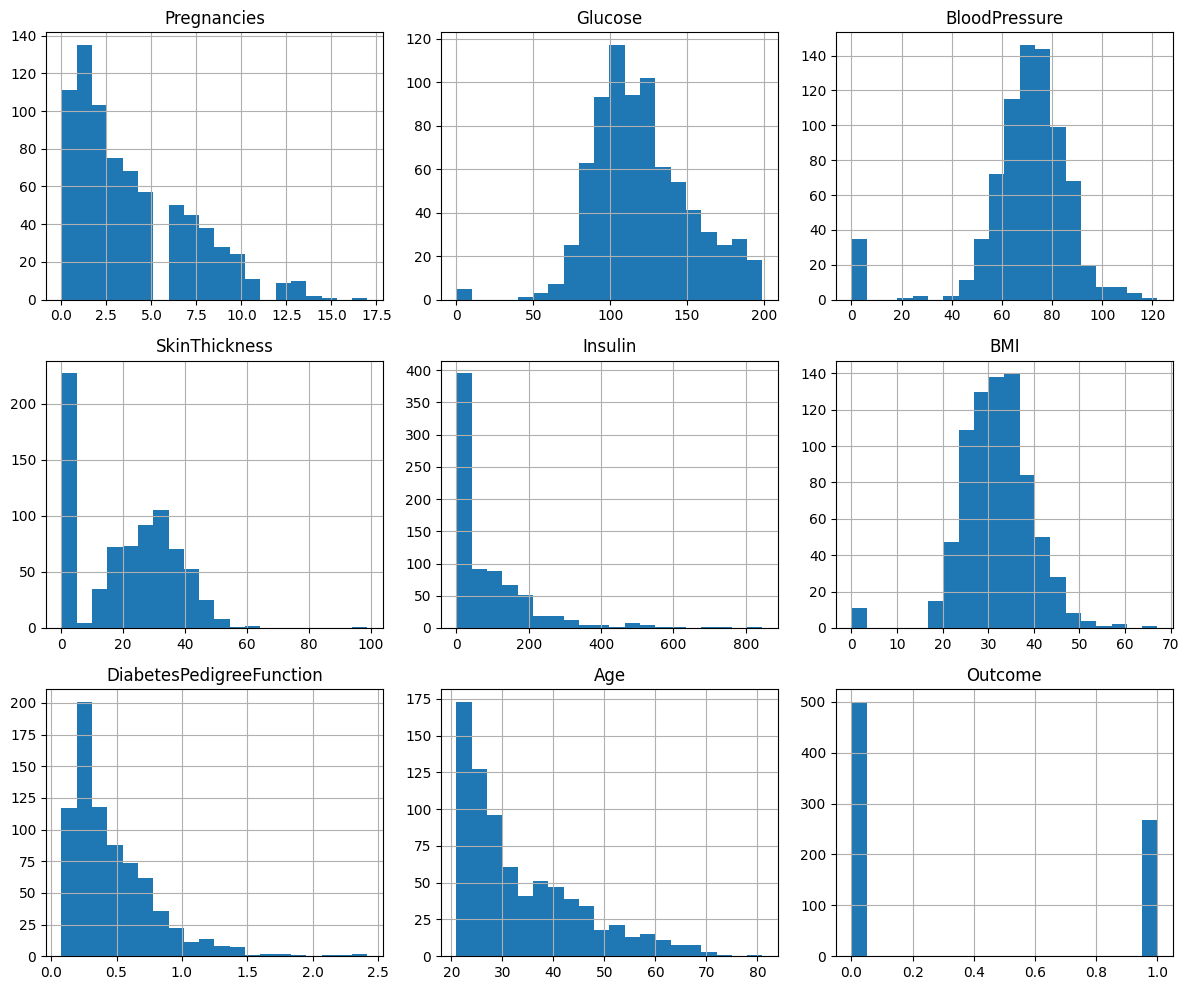

In [8]:
data.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

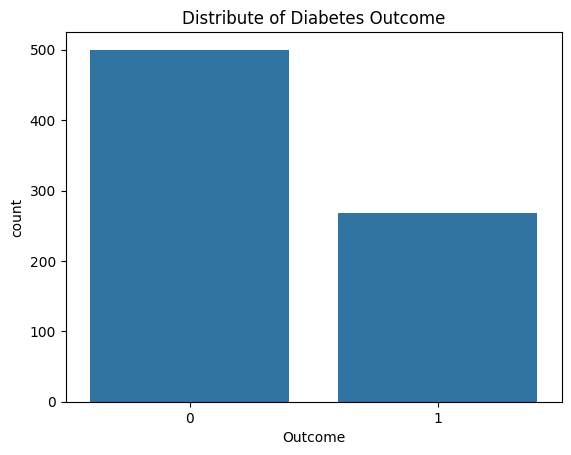

In [9]:
sns.countplot(x="Outcome", data = data)
plt.title("Distribute of Diabetes Outcome")
plt.show()

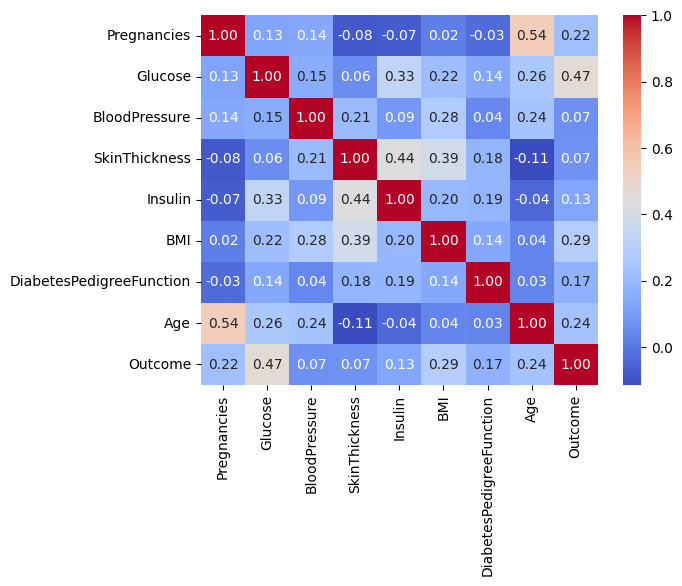

In [10]:
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

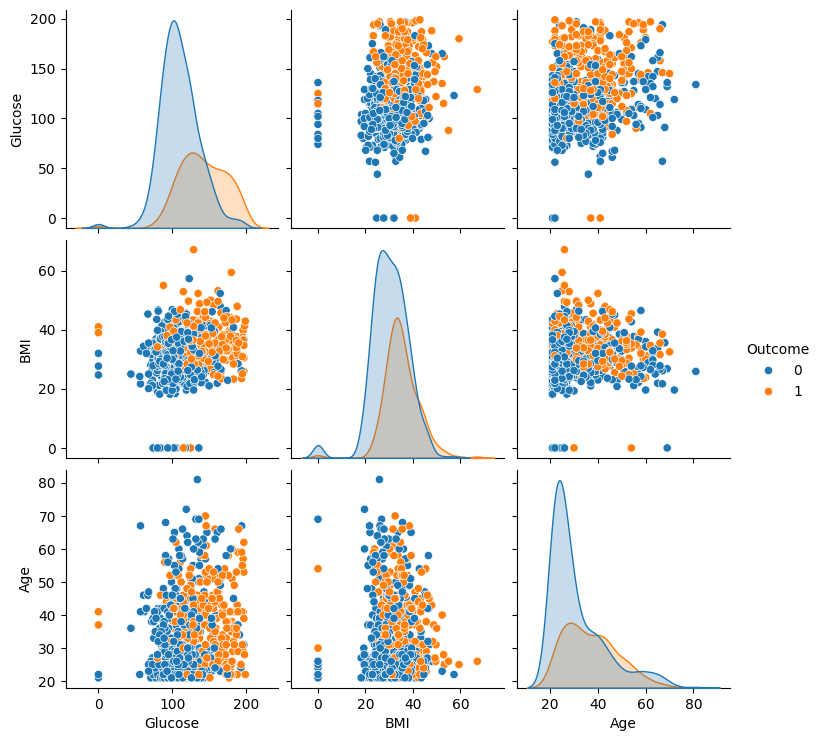

In [11]:
sns.pairplot(data[['Glucose', "BMI", "Age", "Outcome"]], hue="Outcome")
plt.show()

In [12]:
for col in ["Glucose", "SkinThickness", "Insulin", "BMI","DiabetesPedigreeFunction","Pregnancies"]:
    print(col, (data[col] == 0).sum())

Glucose 5
SkinThickness 227
Insulin 374
BMI 11
DiabetesPedigreeFunction 0
Pregnancies 111


In [13]:
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI","DiabetesPedigreeFunction","Pregnancies"]:
    median = data[col].mean()
    data[col] = data[col].replace(0, median)
    

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_data = scaler.fit_transform(data.drop("Outcome", axis=1))

scale_data
# (میانگین 0 انحراف معیار 1)

array([[ 0.5362511 ,  0.86527574, -0.0210444 , ...,  0.16725546,
         0.46849198,  1.4259954 ],
       [-1.1403533 , -1.20598931, -0.51658286, ..., -0.85153454,
        -0.36506078, -0.19067191],
       [ 1.20689286,  2.01597855, -0.68176235, ..., -1.33182125,
         0.60439732, -0.10558415],
       ...,
       [ 0.20093022, -0.02240928, -0.0210444 , ..., -0.90975111,
        -0.68519336, -0.27575966],
       [-1.1403533 ,  0.14197684, -1.01212132, ..., -0.34213954,
        -0.37110101,  1.17073215],
       [-1.1403533 , -0.94297153, -0.18622389, ..., -0.29847711,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [15]:
X = pd.DataFrame(scale_data, columns=data.columns[:-1])
y = data["Outcome"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
y_pred = model.predict(X_test)


In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred=y_pred)
print(f"Accuracy: {acc}")

Accuracy: 0.7662337662337663


In [20]:
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:{cm}")

Confusion Matrix:[[83 16]
 [20 35]]


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.82        99
           1       0.69      0.64      0.66        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.76       154



In [22]:
class Animal :
    def __init__(self, sound, name):
        self.sound = sound #attr
        self.name = name #attr


class Dog(Animal):
    def __init__(self , age):
        self.age = age 
        super().__init__(sound="wow", name="dog")
    
    def sound_dog(self):
        return f"my animal name: {self.name} , her sound is : {self.sound} , age is :{self.age}"


class Cat(Animal):
    def __init__(self, age):
        self.age = age 
        super().__init__(sound="mewmew", name="cat")
        
    def sound_cat(self):
        return f"my animal name: {self.name} , her sound is : {self.sound} age is: {self.age}"

cat = Cat(4)
dog = Dog(14)
print(dog.sound_dog())
print(cat.sound_cat())


my animal name: dog , her sound is : wow , age is :14
my animal name: cat , her sound is : mewmew age is: 4


In [23]:
class LibraryItem:
    def __init__(self, title, author):
        self.title = title
        self.author = author
        self._is_borrowed = False
    
    def brrow_item(self):
        if not self._is_borrowed:
            self._is_borrowed = True
            return f'{self.title} از{self.author} به امانت گرفته شد'
        return f'{self.title}از  {self.author} قبلا امانت گرفته شد'

class Book(LibraryItem):
    def __init__(self, pages):
        self.pages = pages
        super().__init__(title="ashrafzadegan", author="arefabadian")

    def get_info(self):
        return f"this book has a {self.pages} "

b = Book(110)
print(b.get_info())
print(b.brrow_item())

this book has a 110 
ashrafzadegan ازarefabadian به امانت گرفته شد


In [24]:
import re

txt = "The rain in Spain"

x = re.findall('^The.*Spain$', txt)
x

['The rain in Spain']

a.c ==> abc==axc,!=ac
^ شروع رشته ^Hello
$ نشان دهنده پایان جمله
* بمعنی 0 یا بیشتر
a*c ==> ac ==abc abbbc
+ یک کاراکتر یا بیشتر از کاراکتر قبلی
ab+c  ==> abbc == abc== abbbbbbbbbbc !=ac 
{n}  a{3} aaa 
{n,} a{2,} aaaaaaaa == aa
a{2,4} aa aaa aaaa !=aaaaaa
[abc]  
[^abc] 
\d{2} [0-9] 
\D [^0-9]
\w [a-zA-Z0-9_] !=!@#$%^&*-=+
\W [^a-zA-Z0-9_]
\s \s+
\S 

In [25]:
x = re.search(r'\d+', 'There are 123 apples')
x.group()

'123'

In [26]:
x = re.match(r'There', 'There are 123 apples')
x.group()

'There'

In [27]:
re.findall(r'\d+', 'There are 123 apples and 456 oranges')

['123', '456']

In [28]:
re.sub(r'apples', 'bananas', "There are 123 apples")

'There are 123 bananas'

In [29]:
text = 'Call me at 123-456-7890 or 987-654-3214'
re.findall(r'\d{3}-\d{3}-\d{4}', text)

['123-456-7890', '987-654-3214']

In [30]:
sentence = "My mother-in-law is a well-known doctor and 123-test is a project."
# re.findall(r'\b[\w-]+\b', sentence)
re.findall(r'\b\w+-\w+\b', sentence)

['mother-in', 'well-known', '123-test']

In [31]:
txt = 'my email is example@gmail.com i am going to be there for master application'

re.findall(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9]+\.[a-zA-Z0-9]+', txt)

['example@gmail.com']

In [35]:
re.findall(r'\bg\w+',txt)

['gmail', 'going']

In [39]:
txt = "The rain in Spain"
# re.split('\s', txt)
# txt.split(":")

In [45]:
re.sub('\s', "#", txt, 2)

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\G N A\AppData\Local\Temp\ipykernel_17604\4084710427.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  re.sub('\s', "#", txt, 3)
C:\Users\G N A\AppData\Local\Temp\ipykernel_17604\4084710427.py:1: DeprecationWarning: 'count' is passed as positional argument
  re.sub('\s', "#", txt, 3)


'The#rain#in#Spain'

In [51]:
txt = "4 times before 11:45 AM"
# re.findall('[^a-m]', txt)
# re.findall('S.*', txt)
re.findall(r'[1-5]{2}:[3-9]{2}', txt)

['11:45']

In [52]:
txt = """Abasnezhad, Siyamak	Siyamak@poing.com	(555) 555-5555	Teacher, poing	@SiyamakAbasnezhad
McFarland, Dave	dave@poing.com	(555) 555-5554	Teacher, poing
Arthur, King	king_arthur@camelot.co.uk		King, Camelot
Österberg, Sven-Erik	governor@norrbotten.co.se		Governor, Norrbotten	@sverik
, Tim	tim@killerrabbit.com		Enchanter, Killer Rabbit Cave
Carson, Ryan	ryan@poing.com	(555) 555-5543	CEO, poing	@ryancarson
Doctor, The	doctor+companion@tardis.co.uk		Time Lord, Gallifrey
Exampleson, Example	me@example.com	555-555-5552	Example, Example Co.	@example
Hassan, Rohani	president@ir.gov	555 555-5551	President, Iran 	@unknown
Chalkley, Andrew	andrew@poing.com	(555) 555-5553	Teacher, poing	@chalkers
Vader, Darth	darth-vader@empire.gov	(555) 555-4444	Sith Lord, Galactic Empire	@darthvader
Fernández de la Vega Sanz, María Teresa	mtfvs@spain.gov		First Deputy Prime Minister, Spanish Govt."""

In [94]:
# re.findall(r'\(?\d{3}\)?-?\s?\d{3}\-\d{4}', txt)
re.findall(r'[a-zA-Z]+\@+\w+.\w+', txt)

['Siyamak@poing.com',
 'dave@poing.com',
 'arthur@camelot.co',
 'governor@norrbotten.co',
 'tim@killerrabbit.com',
 'ryan@poing.com',
 'companion@tardis.co',
 'me@example.com',
 'president@ir.gov',
 'andrew@poing.com',
 'vader@empire.gov',
 'mtfvs@spain.gov']

In [95]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [103]:
iris = load_iris()
# iris.target_names
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# dir(iris)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [104]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


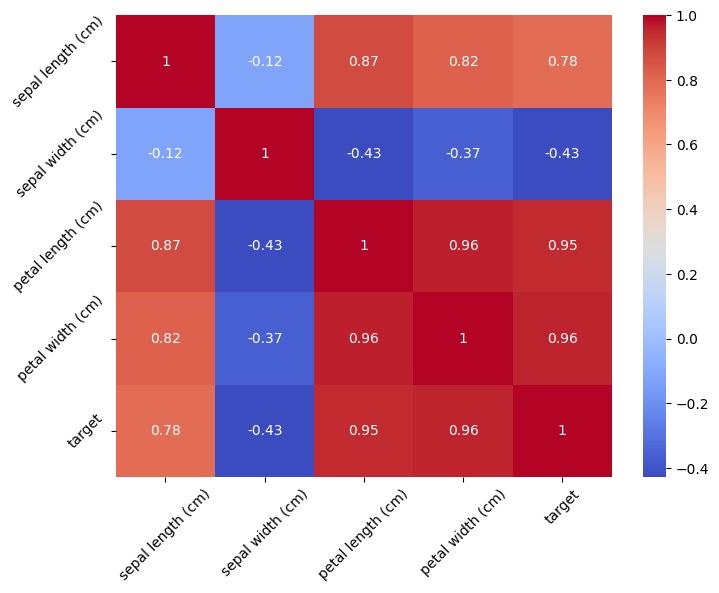

In [111]:
corr = df.drop('target', axis= 1).corr()
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

In [ ]:
for i , col in enumerate(df.columns[:-1], 1):
    print(i)
    plt.boxplot(2,2,1)
    sns.boxplot(x="target", y=col, data=df, palette="Set2")
    plt.title(f"Box plot of {col}")

plt.tight_layout()
plt.show()

In [136]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

X = df.drop('target', axis = 1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [137]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [132]:
acc = model.score(X_test, y_test)
acc

1.0

sepal length (cm): 0.0000
sepal width (cm): 0.0167
petal length (cm): 0.9061
petal width (cm): 0.0772


C:\Users\G N A\AppData\Local\Temp\ipykernel_17604\3028571572.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=X.columns, palette="viridis")


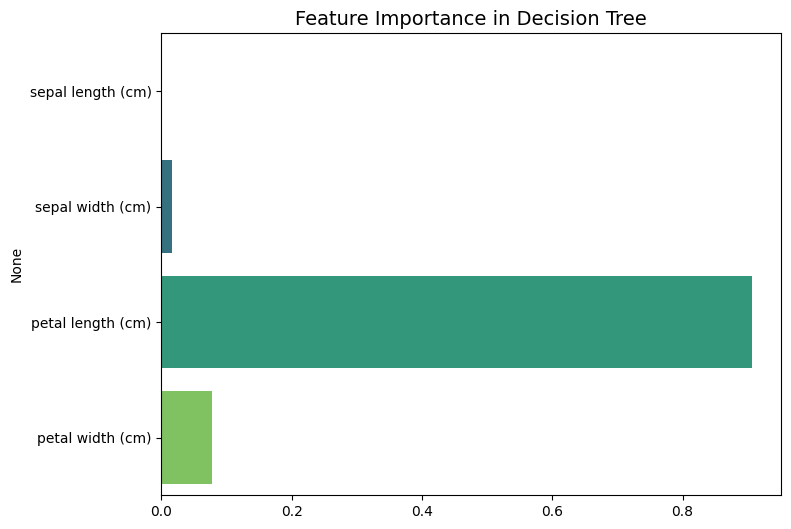

In [138]:
# Feature importance
import numpy as np

feature_importance = model.feature_importances_
for name, importance in zip(X.columns, feature_importance):
    print(f"{name}: {importance:.4f}")

# Plot feature importance
plt.figure(figsize=(8,6))
sns.barplot(x=feature_importance, y=X.columns, palette="viridis")
plt.title("Feature Importance in Decision Tree", fontsize=14)
plt.show()

TypeError: can only concatenate str (not "numpy.int64") to str

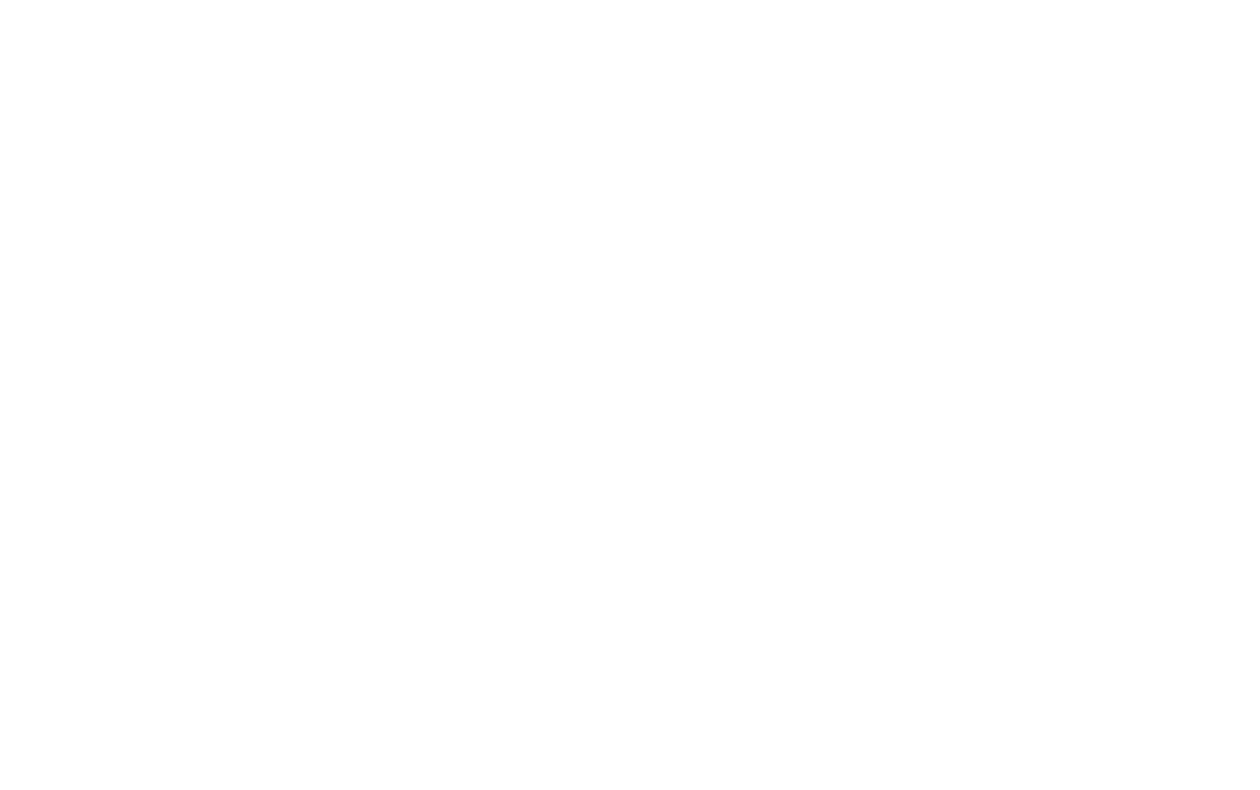

In [139]:
# Plot the trained decision tree
plt.figure(figsize=(16,10))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True, rounded=True)
plt.title("Decision Tree for Iris Dataset", fontsize=16)
plt.show()